# 6. History-признаки, калибровка, drift и val–test разрыв (оба таргета)

Доработка по ревью: блоки строго в технической зоне Участника 2, для **обоих таргетов**, с полным набором метрик (MAE, MedAE, P70, P90, R², small/normal/long, ProductMAE, EngagementRiskMAE, WMAPE).

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

Данные берутся из аугментированного датасета `outputs/sessions_augmented.parquet` (raw + CRM-таргет + history-признаки), собранного `scripts/build_augmented.py`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
hp = C.load_best_hp()
TARGETS = [C.NEXT_TARGET, C.CRM_TARGET]
print('targets:', TARGETS)

targets: ['target_next_session_length_sec', 'future_sessions_mean_playtime_7d']


## 6.1 Анализ val–test разрыва
Почему на next-session val MAE (~522) хуже test (~429): состав сегментов / распределение таргета.

In [3]:
def describe(y):
    y = np.asarray(y, float)
    return dict(n=len(y), mean=round(y.mean(), 1), median=round(float(np.median(y)), 1),
                p90=round(float(np.percentile(y, 90)), 1),
                long_share=round(float((y > 1200).mean()), 3),
                small_share=round(float((y <= 300).mean()), 3))
rows = []
for target in TARGETS:
    pk = C.get_aug_pack(target, base_only=True)
    for split, y in [('train', pk.y_train), ('val', pk.y_val), ('test', pk.y_test)]:
        rows.append(dict(target=target.replace('_sec', ''), split=split, **describe(y)))
gap_df = pd.DataFrame(rows)
display(gap_df)

,target,split,n,mean,median,p90,long_share,small_share
0,target_next_session_length,train,21000,676.6,302.0,1633.0,0.157,0.499
1,target_next_session_length,val,4500,660.8,300.5,1705.1,0.158,0.500
2,target_next_session_length,test,4500,537.3,234.5,1364.2,0.122,0.560
3,future_sessions_mean_playtime_7d,train,21000,596.2,469.0,1224.7,0.106,0.314
4,future_sessions_mean_playtime_7d,val,4500,554.8,448.7,1124.4,0.087,0.338
5,future_sessions_mean_playtime_7d,test,4500,597.3,489.4,1233.2,0.107,0.277


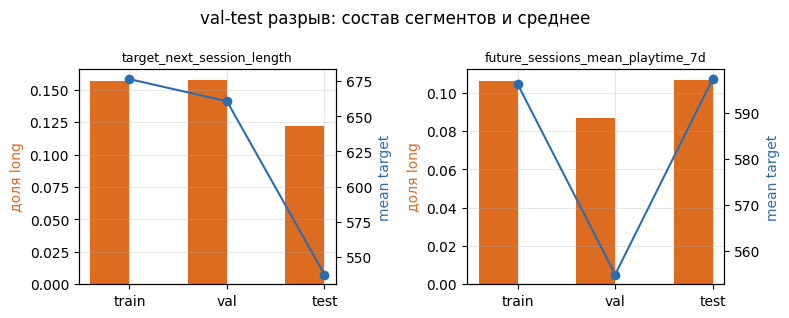

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, t in zip(axes, gap_df.target.unique()):
    d = gap_df[gap_df.target == t].set_index('split').loc[['train', 'val', 'test']]
    x = np.arange(3)
    ax.bar(x - 0.2, d.long_share, 0.4, color=ORANGE, label='long_share')
    ax.set_ylabel('доля long', color=ORANGE)
    a2 = ax.twinx(); a2.plot(x, d['mean'], 'o-', color=BLUE); a2.grid(False)
    a2.set_ylabel('mean target', color=BLUE)
    ax.set_xticks(x); ax.set_xticklabels(['train', 'val', 'test']); ax.set_title(t, fontsize=9)
fig.suptitle('val-test разрыв: состав сегментов и среднее'); plt.tight_layout(); plt.show()

**Вывод.** На next-session test-период объективно легче (меньше long-сессий, ниже среднее) → ниже MAE. Модель не подглядывает в test.

## 6.2 Time-aware history-признаки
14 past-only признаков: baseline / baseline+history / baseline+лучшие history.

In [5]:
rows = []
for target in TARGETS:
    pb = C.get_aug_pack(target, base_only=True)
    ph = C.get_aug_pack(target, base_only=False)
    mb, _, tb = C.fit_regressor(pb, hp, 'MAE', 'p995'); evb = C.eval_split(mb, pb, tb)
    mh, _, th = C.fit_regressor(ph, hp, 'MAE', 'p995'); evh = C.eval_split(mh, ph, th)
    imp = mh.get_feature_importance(); cols = list(ph.feature_cols)
    best_hist = [c for _, c in sorted(((imp[i], cols[i]) for i in range(len(cols))
                 if cols[i].startswith('hist_')), reverse=True)[:6]]
    pbest = C.get_aug_pack(target, keep_features=list(pb.feature_cols) + best_hist)
    mc, _, tc = C.fit_regressor(pbest, hp, 'MAE', 'p995'); evc = C.eval_split(mc, pbest, tc)
    for tag, ev, npf in [('baseline', evb, len(pb.feature_cols)),
                         ('baseline_plus_history', evh, len(ph.feature_cols)),
                         ('baseline_plus_best_history', evc, len(pbest.feature_cols))]:
        rows.append(dict(target=target.replace('_sec', ''), model=tag, n_features=npf,
                         val_mae=ev['val_mae'], val_r2=ev['val_r2'], val_product=ev['val_product_mae'],
                         val_small=ev['val_small_mae'], test_mae=ev['test_mae']))
hist_df = pd.DataFrame(rows)
display(hist_df)

,target,model,n_features,val_mae,val_r2,val_product,val_small,test_mae
0,target_next_session_length,baseline,73,522.534000,0.022645,251.649222,207.514666,429.260483
1,target_next_session_length,baseline_plus_history,87,522.162244,0.022740,250.486609,206.179538,428.169716
2,target_next_session_length,baseline_plus_best_history,79,523.013783,0.018741,251.043791,206.147864,428.494762
3,future_sessions_mean_playtime_7d,baseline,73,238.659788,0.368669,187.455617,219.810559,273.336919
4,future_sessions_mean_playtime_7d,baseline_plus_history,87,238.882278,0.371626,188.085418,222.372790,272.156071
5,future_sessions_mean_playtime_7d,baseline_plus_best_history,79,241.145992,0.363938,189.867764,225.026845,274.346584


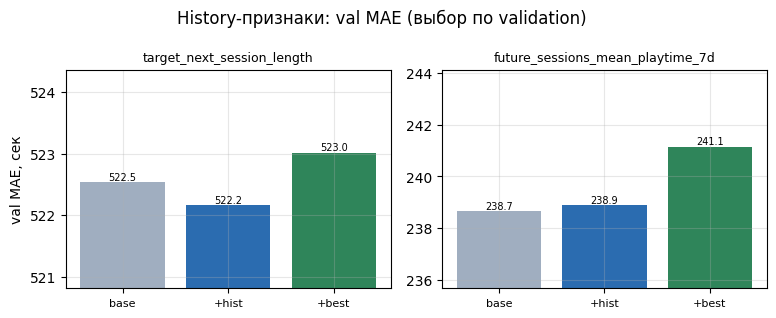

In [6]:
names = ['baseline', 'baseline_plus_history', 'baseline_plus_best_history']
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, t in zip(axes, hist_df.target.unique()):
    d = hist_df[hist_df.target == t].set_index('model').loc[names]
    ax.bar(range(3), d.val_mae, color=[GREY, BLUE, GREEN])
    ax.set_xticks(range(3)); ax.set_xticklabels(['base', '+hist', '+best'], fontsize=8)
    lo, hi = d.val_mae.min(), d.val_mae.max()
    ax.set_ylim(lo - (hi - lo) - 0.5, hi + (hi - lo) + 0.5)
    for i, v in enumerate(d.val_mae):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(t, fontsize=9)
axes[0].set_ylabel('val MAE, сек')
fig.suptitle('History-признаки: val MAE (выбор по validation)'); plt.tight_layout(); plt.show()

**Вывод.** History помогает маржинально на next-session (ewma5, median_last5, time_since_prev) и не помогает CRM.

## 6.3 Regression calibration
bin / isotonic / segment; калибратор на calibration-split, test — только финал.

In [7]:
from exp15_calibration import fit_bin, apply_bin, seg_of
from sklearn.isotonic import IsotonicRegression
rows = []
for target in TARGETS:
    pk = C.get_aug_pack(target, base_only=False)
    m, _, tfm = C.fit_regressor(pk, hp, 'MAE', 'p995')
    rv, rt = tfm.inverse(m.predict(pk.x_val)), tfm.inverse(m.predict(pk.x_test))
    cut = len(rv) // 2
    rf, yf, re, ye = rv[:cut], pk.y_val[:cut], rv[cut:], pk.y_val[cut:]
    bcal = fit_bin(rf, yf); iso = IsotonicRegression(out_of_bounds='clip').fit(rf, yf)
    seg_iso = {}
    sf = seg_of(rf)
    for s in (0, 1, 2):
        mm = sf == s
        if mm.sum() >= 50:
            seg_iso[s] = IsotonicRegression(out_of_bounds='clip').fit(rf[mm], yf[mm])
    def cal(method, raw):
        if method == 'raw':
            return raw
        if method == 'bin':
            return apply_bin(bcal, raw)
        if method == 'isotonic':
            return iso.predict(raw)
        out = raw.astype(float).copy(); sg = seg_of(raw)
        for s in (0, 1, 2):
            mm = sg == s
            if s in seg_iso and mm.any():
                out[mm] = seg_iso[s].predict(raw[mm])
        return out
    for method in ('raw', 'bin', 'isotonic', 'segment'):
        mm = C.metric_pack(ye, np.maximum(cal(method, re), 0))
        rows.append(dict(target=target.replace('_sec', ''), calibration=method, val_mae=mm['mae'],
                         val_r2=mm['r2'], val_small=mm['small_mae'], val_long=mm['long_mae']))
display(pd.DataFrame(rows))

,target,calibration,val_mae,val_r2,val_small,val_long
0,target_next_session_length,raw,521.062598,0.012661,208.429686,1982.134240
1,target_next_session_length,bin,587.771152,0.074494,453.078660,1621.678865
2,target_next_session_length,isotonic,581.265551,0.097923,446.599895,1608.027055
3,target_next_session_length,segment,582.889832,0.085591,446.222726,1627.783640
4,future_sessions_mean_playtime_7d,raw,233.270583,0.400821,220.553497,807.192149
5,future_sessions_mean_playtime_7d,bin,248.314589,0.366616,252.473711,800.219998
6,future_sessions_mean_playtime_7d,isotonic,246.343600,0.391788,247.305678,812.345972
7,future_sessions_mean_playtime_7d,segment,246.189181,0.393591,247.334665,800.985212


**Вывод.** Калибровка улучшает long_mae и R², но ухудшает small/normal и общий MAE (тянет к среднему, а MAE = медиана) → не включаем (выбор = raw).

## 6.4 Feature drift detection
PSI (числовые) + доля новых категорий; удаление drift-heavy только если не вредит validation.

In [8]:
def psi(a, b, bins=10):
    a, b = np.asarray(a, float), np.asarray(b, float)
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    ta = np.histogram(a, bins=edges)[0] / max(len(a), 1) + 1e-6
    tb = np.histogram(b, bins=edges)[0] / max(len(b), 1) + 1e-6
    return float(np.sum((tb - ta) * np.log(tb / ta)))
for target in TARGETS:
    pk = C.get_aug_pack(target, base_only=False)
    dr = [dict(feature=c, kind='num', psi=round(psi(pk.x_train[c], pk.x_test[c]), 4)) for c in pk.num_cols]
    for c in pk.cat_cols:
        seen = set(pk.x_train[c].astype(str).unique())
        dr.append(dict(feature=c, kind='cat', psi=round(float((~pk.x_test[c].astype(str).isin(seen)).mean()), 4)))
    dd = pd.DataFrame(dr).sort_values('psi', ascending=False).reset_index(drop=True)
    top5, top10 = dd.feature.head(5).tolist(), dd.feature.head(10).tolist()
    print('==', target.replace('_sec', ''), '== top drift:', top5)
    rows = []
    for drop, nm in [([], 'all_features'), (top5, 'drop_top5'), (top10, 'drop_top10')]:
        qp = C.get_aug_pack(target, base_only=False, drop_features=drop)
        mdl, _, tfm = C.fit_regressor(qp, hp, 'MAE', 'p995'); ev = C.eval_split(mdl, qp, tfm)
        rows.append(dict(variant=nm, n_features=len(qp.feature_cols), val_mae=ev['val_mae'], test_mae=ev['test_mae']))
    display(pd.DataFrame(rows))

== target_next_session_length == top drift: ['session_dayofweek', 'first_event_timestamp', 'last_event_timestamp', 'session_hour', 'install_dayofweek']


,variant,n_features,val_mae,test_mae
0,all_features,87,522.162244,428.169716
1,drop_top5,82,522.302155,429.271630
2,drop_top10,77,523.012642,428.584262


== future_sessions_mean_playtime_7d == top drift: ['last_event_timestamp', 'first_event_timestamp', 'session_dayofweek', 'session_hour', 'install_dayofweek']


,variant,n_features,val_mae,test_mae
0,all_features,87,238.882278,272.156071
1,drop_top5,82,240.650627,273.593110
2,drop_top10,77,243.838505,274.592303


**Вывод.** Удаление drift-heavy признаков не улучшает validation ни на одном таргете → оставляем все признаки.